## Predicting Algorithms

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pos_fraction = np.linspace(0.00, 1.00, 1000)

In [3]:
gini = 1 - pos_fraction**2 - (1-pos_fraction)**2

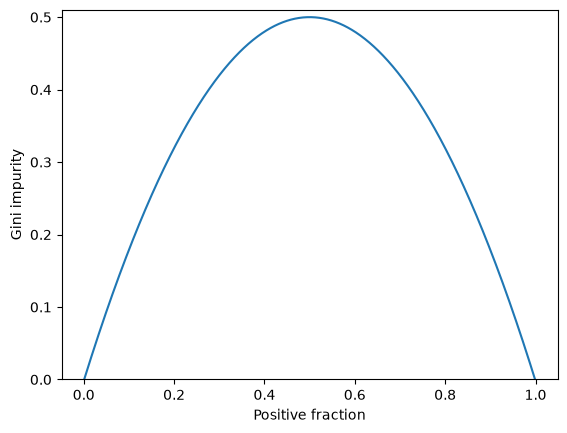

In [11]:
plt.plot(pos_fraction, gini)
plt.ylim(0, 0.51)
plt.xlabel('Positive fraction')
plt.ylabel('Gini impurity')
plt.show()

In [5]:
def gini_impurity(labels):
    # When the set is empty, it is also pure
    if len(labels) == 0:
        return 0
    # Count the occurrences of each label
    counts = np.unique(labels, return_counts=True)[1]
    fractions = counts / float(len(labels))
    return 1 - np.sum(fractions ** 2)

In [7]:
print(f'{gini_impurity([1,1,0,0,1]):.2f}')

0.48


### Information Gain

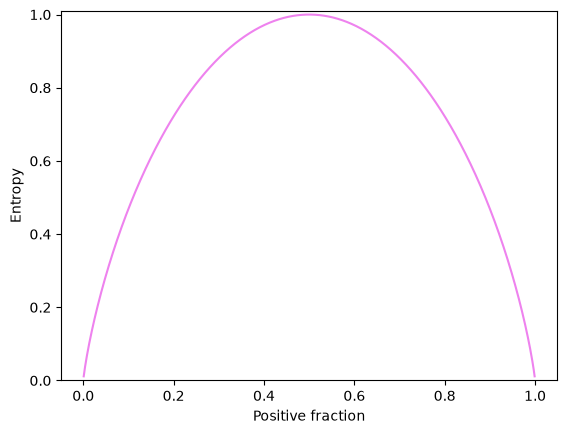

In [10]:
pos_fraction = np.linspace(0.001, 0.999, 1000)
ent = - (pos_fraction * np.log2(pos_fraction) + (1 - pos_fraction) * np.log2(1 - pos_fraction))

plt.plot(pos_fraction, ent, color="violet")
plt.xlabel('Positive fraction')
plt.ylabel('Entropy')
plt.ylim(0, 1.01)
plt.show()

In [12]:
def entropy(labels):
    if len(labels) == 0:
        return 0
    counts = np.unique(labels, return_counts=True)[1]
    fractions = counts / float(len(labels))
    return - np.sum(fractions * np.log2(fractions))

In [13]:
print(f'{entropy([1, 1, 0, 1, 0, 0]):.4f}')
print(f'{entropy([1, 1, 0, 1, 0]):.4f}')

1.0000
0.9710


In [14]:
criterion_function = {'gini': gini_impurity,'entropy': entropy}
def weighted_impurity(groups, criterion='gini'):
    """
    Calculate weighted impurity of children after a split
    @param groups: list of children, and a child consists a
    list of class labels
    @param criterion: metric to measure the quality of a split,
    'gini' for Gini impurity or 'entropy' for
    information gain
    @return: float, weighted impurity
    """
    total = sum(len(group) for group in groups)
    weighted_sum = 0.0
    for group in groups:
        weighted_sum += len(group) / float(total) * criterion_function[criterion](group)
    return weighted_sum

In [30]:
def split_node(X, y, index, value):
    x_index = X[:, index]
    # if this feature is numerical
    if X[0, index].dtype.kind in ['i', 'f']:
        mask = x_index >= value
    # if this feature is categorical
    else:
        mask = x_index == value
    # split into left and right child
    left = [X[~mask, :], y[~mask]]
    right = [X[mask, :], y[mask]]
    return left, right

In [31]:
def get_best_split(X, y, criterion):
    best_index, best_value, best_score, children = None, None, 1, None
    for index in range(len(X[0])):
        for value in np.sort(np.unique(X[:, index])):
            groups = split_node(X, y, index, value)
            impurity = weighted_impurity([groups[0][1], groups[1][1]], criterion)
            if impurity < best_score:
                best_index, best_value, best_score, children = index, value, impurity, groups
    return {
        'index': best_index, 
        'value': best_value,
        'children': children
        }